# SEABORN WORK NOTEBOOK
---
### Where i will be showcasing my work in seaborn i would be taking a data generated by api which deals with weather related stuff i would not be publishing .env file contain api code including api key due to obvious reason

> This is api link https://meteostat.p.rapidapi.com/point/monthly used to generate weather data set! 

this code is also present at my kaggle profile : https://www.kaggle.com/thedhawalpanchamiya 

If someone feels to use it you make use it by 


```
Install dependencies as needed:
pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

Set the path to the file you'd like to load
file_path = ""

 Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "thedhawalpanchamiya/weather-data-set",
  file_path,
   Provide any additional arguments like 
   sql_query or pandas_kwargs. See the 
   documenation for more information:
  https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())



> It contains weather report of coordinates "lat":"52.5244","lon":"13.4105" from date jan - 2020 to dec - 2025

---

### Lets start with importing lib needed

In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import scipy as spy
import sklearn as skl

--- 

### After importing Lib, Now lets load data in dataframe


In [3]:
data = pd.read_csv("weather_data.csv")
data.head()

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun
0,2020-01-01,4.6,2.4,6.8,49.0,NaN,1021.1,3678
1,2020-02-01,6.3,4.0,8.6,89.2,NaN,1010.0,2820
2,2020-03-01,5.7,2.1,9.5,47.6,NaN,1017.8,9966
3,2020-04-01,10.7,5.2,16.3,7.7,NaN,1018.4,17754
4,2020-05-01,12.3,7.3,16.7,26.9,NaN,1019.3,13554


---

### Lets have a quick look at data if needeed we will be dealing be preprocessing as well

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    72 non-null     str    
 1   tavg    72 non-null     float64
 2   tmin    72 non-null     float64
 3   tmax    72 non-null     float64
 4   prcp    72 non-null     float64
 5   wspd    0 non-null      float64
 6   pres    72 non-null     float64
 7   tsun    72 non-null     int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 4.6 KB


In this data we have one complete column thats empty we can remove it

In [5]:
data = data.drop(columns = ["wspd"])

In [6]:
data.head()

,date,tavg,tmin,tmax,prcp,pres,tsun
0,2020-01-01,4.6,2.4,6.8,49.0,1021.1,3678
1,2020-02-01,6.3,4.0,8.6,89.2,1010.0,2820
2,2020-03-01,5.7,2.1,9.5,47.6,1017.8,9966
3,2020-04-01,10.7,5.2,16.3,7.7,1018.4,17754
4,2020-05-01,12.3,7.3,16.7,26.9,1019.3,13554


so we have succesfully removed wspd from this data

---
### Now Lets began with other required stuff

-DISTRIBUTION ANALYSIS-

> Q1 Plot the distribution of average temperature (tavg) using a histogram

<Axes: xlabel='tavg', ylabel='Count'>

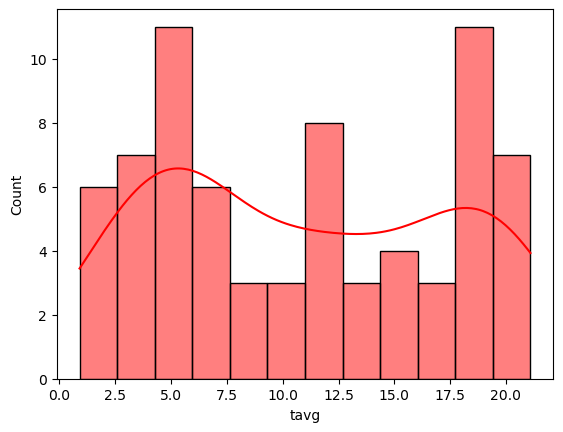

In [7]:
sns.histplot(data=data,x= data["tavg"],color="red",bins = 12,kde = True)

From this we observe a trend of 1.25 - 7.5 looks good in number after that it decreases and again increases around 17.5 - 20.0

> Q2 Compare distributions of tavg, tmin, and tmax.

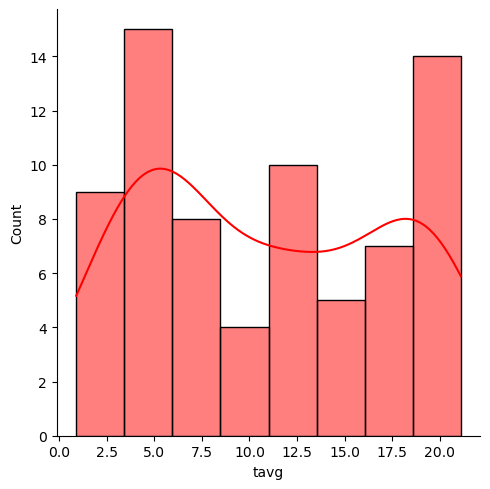

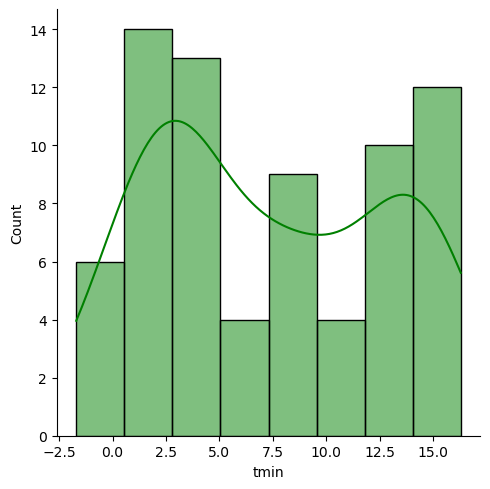

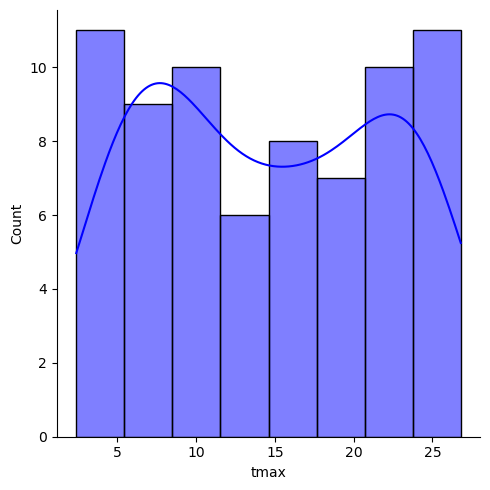

In [8]:
sns.displot(data=data, x="tavg", color="red", kde=True)
sns.displot(data=data, x="tmin", color="green", kde=True)
sns.displot(data=data, x="tmax", color="blue", kde=True)

<Axes: xlabel='tavg', ylabel='Density'>

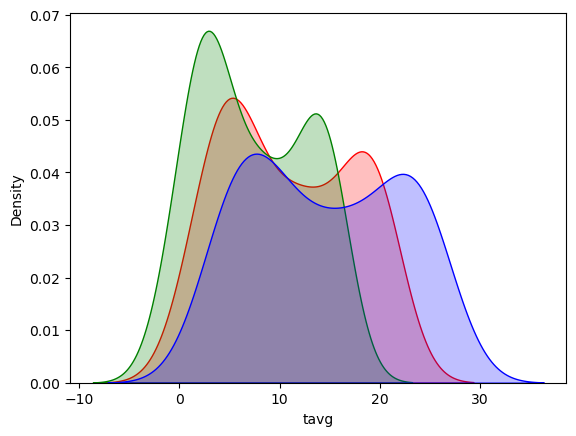

In [9]:
sns.kdeplot(data=data, x="tavg", color="red", label="Average" , fill = True)
sns.kdeplot(data=data, x="tmin", color="green", label="Minimum", fill = True)
sns.kdeplot(data=data, x="tmax", color="blue", label="Maximum", fill = True)

> Q3 Visualize rainfall (prcp) distribution and identify whether it is skewed.

<Axes: xlabel='prcp', ylabel='Density'>

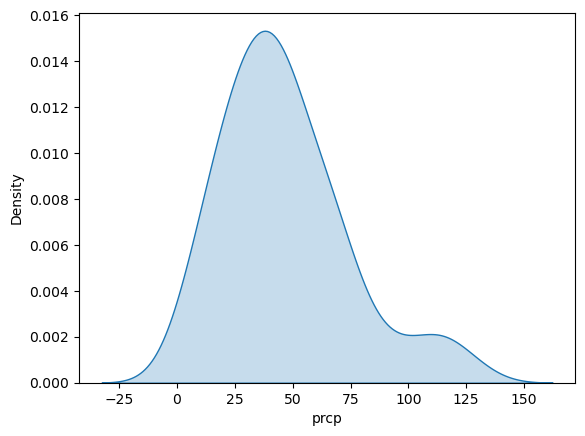

In [10]:
sns.kdeplot(data=data, x="prcp", fill=True)

<Axes: xlabel='prcp'>

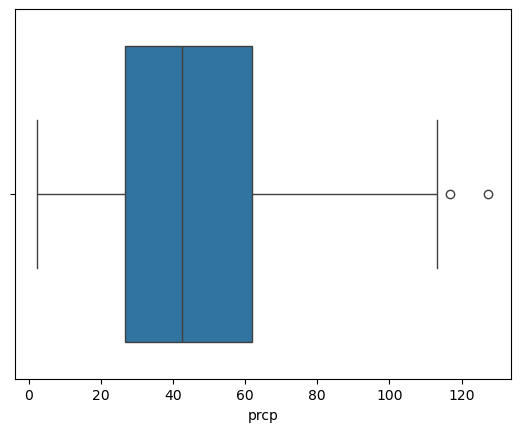

In [11]:
sns.boxplot(data=data, x="prcp")

In [12]:
data["prcp"].skew()

np.float64(0.9668837566958123)

Rainfall (prcp) exhibits a positive skewness of 0.967, indicating a right-skewed distribution. Most observations correspond to low precipitation levels, while a small number of days experience significantly higher rainfall, resulting in a long right tail.

> Q4 Create boxplots for all numerical columns and identify outliers.

for this kind for work we need matplotlib subplot element:

In [13]:
import matplotlib.pyplot as plt

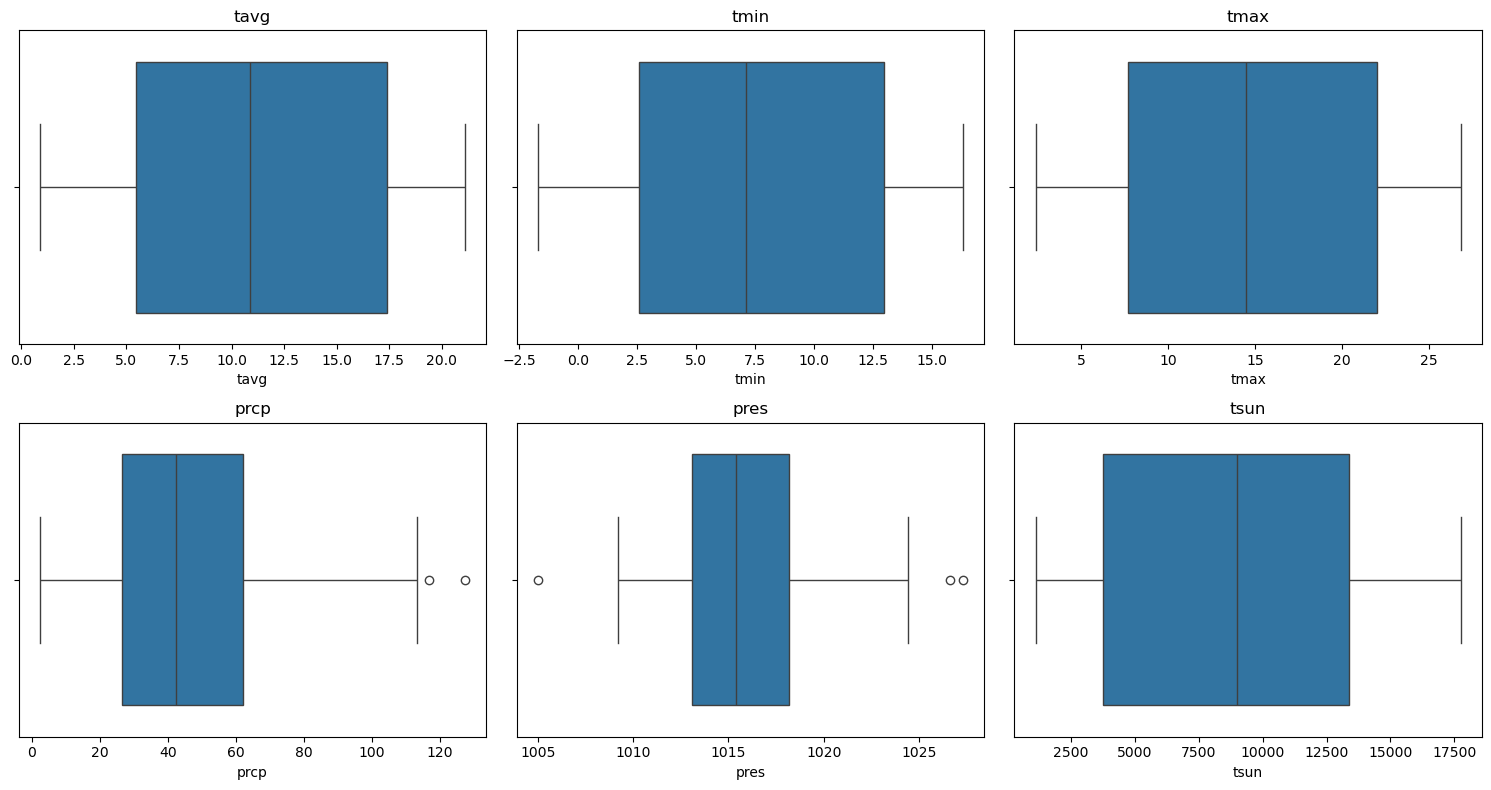

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), data.select_dtypes(include="number").columns):
    sns.boxplot(x=data[col], ax=ax )
    ax.set_title(col)

plt.tight_layout()

for outliers we need 25%ile - (1.5 * 75%ile - 25%ile) as lower bound and 75%ile + 1.5 * (75%ile - 25%ile) , this is termed as IQR Method

In [15]:
num_cols = data.select_dtypes(include="number").columns

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()

    print(f"{col}: {n_outliers} outliers")

tavg: 0 outliers
tmin: 0 outliers
tmax: 0 outliers
prcp: 2 outliers
pres: 3 outliers
tsun: 0 outliers


---
Time Series Trends

> Q5 How does average temperature change over time?

<Axes: xlabel='date', ylabel='tavg'>

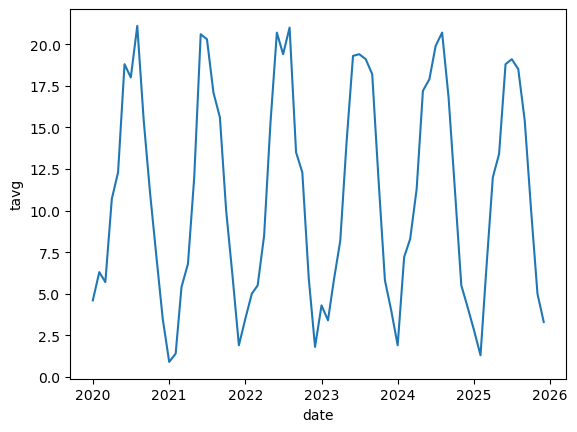

In [16]:
data["date"] = pd.to_datetime(data["date"])

sns.lineplot(data=data, x="date", y="tavg")

We observe regular ups and downs in this data

> Q6. Plot minimum and maximum temperatures together over time.

<Axes: xlabel='date', ylabel='tmin'>

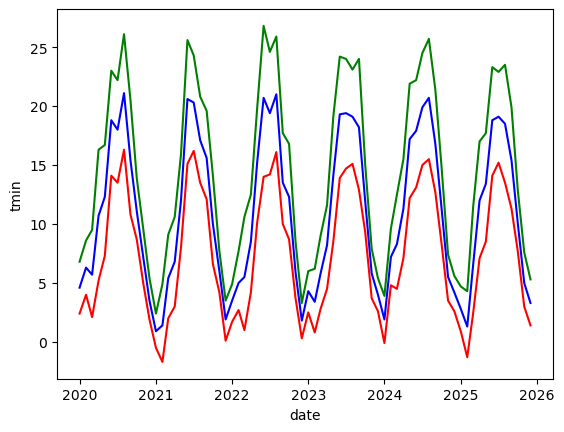

In [22]:
sns.lineplot(data = data , x = "date" , y = "tmin" , color = "red")
sns.lineplot(data = data , x = "date" , y = "tmax" , color = "green")
sns.lineplot(data = data , x = "date" , y = "tavg" , color = "blue")

> q7 Visualize sunshine duration (tsun) over the years.

<Axes: xlabel='date', ylabel='tsun'>

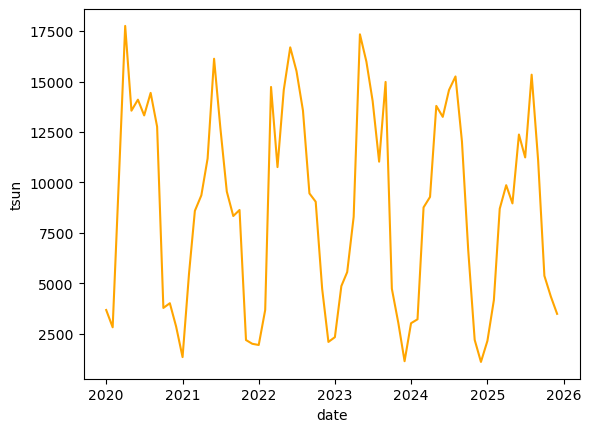

In [38]:
sns.lineplot(data = data, x = "date", y = "tsun", color = "orange")

> Q8. How does atmospheric pressure (pres) vary over time?

<Axes: xlabel='date', ylabel='pres'>

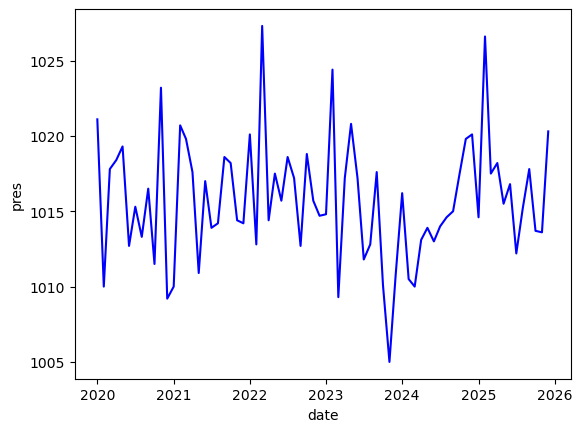

In [39]:
sns.lineplot(data= data, x = "date",y = "pres",color = "blue")